In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    

GPU Available: True
GPU: Tesla T4


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "data.yaml" in files:
        print(root)

/kaggle/input/datasets/banuprasadb/wildlife-dataset


In [3]:
import os

dataset_path = "/kaggle/input/datasets/banuprasadb/wildlife-dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)
    if len(files) > 0:
        print("Sample files:", files[:5])
    print("-" * 50)

/kaggle/input/datasets/banuprasadb/wildlife-dataset
Sample files: ['data.yaml']
--------------------------------------------------
/kaggle/input/datasets/banuprasadb/wildlife-dataset/valid
--------------------------------------------------
/kaggle/input/datasets/banuprasadb/wildlife-dataset/valid/labels
Sample files: ['14ef0fef767ed448.txt', '66737624199fe1ca.txt', 'de622e1e3936e897.txt', 'b02b8fc58e56a15c.txt', 'ac4f45282711d046.txt']
--------------------------------------------------
/kaggle/input/datasets/banuprasadb/wildlife-dataset/valid/images
Sample files: ['021e79e28ccaf54b.jpg', 'dfd186ca2caade13.jpg', '02f74f78a0e59b9f.jpg', '8f5a8ab6c0c0bb82.jpg', 'b02b8fc58e56a15c.jpg']
--------------------------------------------------
/kaggle/input/datasets/banuprasadb/wildlife-dataset/test
--------------------------------------------------
/kaggle/input/datasets/banuprasadb/wildlife-dataset/test/labels
Sample files: ['1c82bc5d4095b2f3.txt', 'dbebeeeaa2cecbd0.txt', '43f3ba731b5db4a4.txt',

In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.6 MB/s eta 0:00:0000:01


In [5]:
import yaml

yaml_path = "/kaggle/input/datasets/banuprasadb/wildlife-dataset/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

print(data)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 54, 'names': {0: 'Zebra', 1: 'Lion', 2: 'Leopard', 3: 'Cheetah', 4: 'Tiger', 5: 'Bear', 6: 'Butterfly', 7: 'Canary', 8: 'Crocodile', 9: 'Bull', 10: 'Camel', 11: 'Centipede', 12: 'Caterpillar', 13: 'Duck', 14: 'Squirrel', 15: 'Spider', 16: 'Ladybug', 17: 'Elephant', 18: 'Horse', 19: 'Fox', 20: 'Tortoise', 21: 'Frog', 22: 'Kangaroo', 23: 'Deer', 24: 'Eagle', 25: 'Monkey', 26: 'Snake', 27: 'Owl', 28: 'Swan', 29: 'Goat', 30: 'Rabbit', 31: 'Giraffe', 32: 'Goose', 33: 'PolarBear', 34: 'Raven', 35: 'Hippopotamus', 36: 'BrownBear', 37: 'Rhinoceros', 38: 'Woodpecker', 39: 'Sheep', 40: 'Magpie', 41: 'Ostrich', 42: 'Jaguar', 43: 'Hedgehog', 44: 'Turkey', 45: 'Raccoon', 46: 'Worm', 47: 'Harbor', 48: 'Panda', 49: 'RedPanda', 50: 'Otter', 51: 'Lynx', 52: 'Scorpion', 53: 'Koala'}}


In [7]:
import yaml

data = {
    "path": "/kaggle/input/datasets/banuprasadb/wildlife-dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 54,
    "names": [
        "Zebra","Lion","Leopard","Cheetah","Tiger","Bear","Butterfly",
        "Canary","Crocodile","Bull","Camel","Centipede","Caterpillar",
        "Duck","Squirrel","Spider","Ladybug","Elephant","Horse","Fox",
        "Tortoise","Frog","Kangaroo","Deer","Eagle","Monkey","Snake",
        "Owl","Swan","Goat","Rabbit","Giraffe","Goose","PolarBear",
        "Raven","Hippopotamus","BrownBear","Rhinoceros","Woodpecker",
        "Sheep","Magpie","Ostrich","Jaguar","Hedgehog","Turkey",
        "Raccoon","Worm","Harbor","Panda","RedPanda","Otter",
        "Lynx","Scorpion","Koala"
    ]
}

with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("New data.yaml created successfully!")

New data.yaml created successfully!


In [8]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    workers=2,
    cache=True,
    device=0,
    project="/kaggle/working",
    name="Wildlife_YOLOv8m"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.112 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, forma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2c50e92840>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,   

In [9]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/Wildlife_YOLOv8m/weights/best.pt")

results = model.predict(
    source="/kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images",
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/001ef0f9885fa3d4.jpg: 480x640 1 Tortoise, 27.0ms
image 2/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/00568e367bea83e2.jpg: 640x480 1 Giraffe, 51.9ms
image 3/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/0064360fc5b84cd6.jpg: 448x640 1 Goose, 54.2ms
image 4/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/007070c

In [11]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "/kaggle/runs/detect/predict"

images = [f for f in os.listdir(pred_dir) if f.endswith((".jpg", ".png"))]

print(f"Predicted images: {len(images)}")

img = Image.open(os.path.join(pred_dir, images[0]))
plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/runs/detect/predict'

In [14]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/Wildlife_YOLOv8m/weights/best.pt")

results = model.predict(
    source="/kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images",
    conf=0.25,
    save=True,
    project="/kaggle/working",
    name="Predictions"
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/001ef0f9885fa3d4.jpg: 480x640 1 Tortoise, 13.1ms
image 2/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/00568e367bea83e2.jpg: 640x480 1 Giraffe, 14.7ms
image 3/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/0064360fc5b84cd6.jpg: 448x640 1 Goose, 13.9ms
image 4/1717 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/007070c

Total predicted images: 1717
First 10 images: ['36b94cd039b8116c.jpg', '2c0832e018552847.jpg', '48f5e239d1d661a4.jpg', '7068b20835ae95fa.jpg', '985642747d9fdab7.jpg', 'c5770ae5ad67cc08.jpg', '39ce9fedcfced39a.jpg', '5cf78103712af792.jpg', 'adc6cb08fcafcf77.jpg', '070730f0b9568b99.jpg']


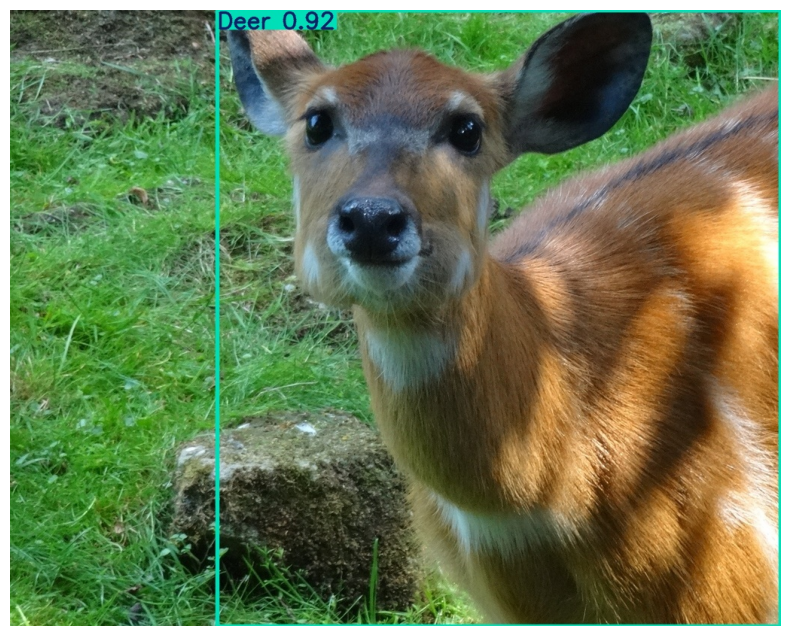

In [17]:
import os
from PIL import Image
import matplotlib.pyplot as plt

pred_dir = "/kaggle/working/Predictions-3"

images = [f for f in os.listdir(pred_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Total predicted images:", len(images))
print("First 10 images:", images[:10])

img = Image.open(os.path.join(pred_dir, images[0]))

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/Wildlife_YOLOv8m/weights/best.pt")

model.predict(
    source="/kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/ffaa7d8efdd5c1ab.jpg",
    conf=0.25,
    save=True
)


image 1/1 /kaggle/input/datasets/banuprasadb/wildlife-dataset/test/images/ffaa7d8efdd5c1ab.jpg: 448x640 1 Fox, 26.5ms
Speed: 2.8ms preprocess, 26.5ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /kaggle/working/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'Zebra', 1: 'Lion', 2: 'Leopard', 3: 'Cheetah', 4: 'Tiger', 5: 'Bear', 6: 'Butterfly', 7: 'Canary', 8: 'Crocodile', 9: 'Bull', 10: 'Camel', 11: 'Centipede', 12: 'Caterpillar', 13: 'Duck', 14: 'Squirrel', 15: 'Spider', 16: 'Ladybug', 17: 'Elephant', 18: 'Horse', 19: 'Fox', 20: 'Tortoise', 21: 'Frog', 22: 'Kangaroo', 23: 'Deer', 24: 'Eagle', 25: 'Monkey', 26: 'Snake', 27: 'Owl', 28: 'Swan', 29: 'Goat', 30: 'Rabbit', 31: 'Giraffe', 32: 'Goose', 33: 'PolarBear', 34: 'Raven', 35: 'Hippopotamus', 36: 'BrownBear', 37: 'Rhinoceros', 38: 'Woodpecker', 39: 'Sheep', 40: 'Magpie', 41: 'Ostrich', 42: 'Jaguar', 43: 'Hedgehog', 44: 'Turkey', 45: 'Raccoon', 46: 'Worm', 47: 'Harbor', 48: 'Panda', 49: 'RedPanda', 50: 'Otter', 51: 'Lynx', 52: 'Scorpion', 53: 'Koala'}
 obb: None
 orig_img: array([[[205, 225, 230],
         [206, 226, 231],
   